In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

In [2]:
# Load processed data
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()


In [3]:
# Training all 3 models
# 1. Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [4]:
# Evaluate all models
models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'Accuracy': round(accuracy * 100, 2),
        'ROC-AUC': round(roc_auc, 4)
    }
    
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Good', 'Bad']))

results_df = pd.DataFrame(results).T
print("\n=== Model Comparison ===")
print(results_df)


=== Logistic Regression ===
Accuracy: 75.36%
ROC-AUC: 0.8264

Classification Report:
              precision    recall  f1-score   support

        Good       0.76      0.74      0.75       140
         Bad       0.75      0.76      0.76       140

    accuracy                           0.75       280
   macro avg       0.75      0.75      0.75       280
weighted avg       0.75      0.75      0.75       280


=== Random Forest ===
Accuracy: 81.43%
ROC-AUC: 0.9030

Classification Report:
              precision    recall  f1-score   support

        Good       0.81      0.81      0.81       140
         Bad       0.81      0.81      0.81       140

    accuracy                           0.81       280
   macro avg       0.81      0.81      0.81       280
weighted avg       0.81      0.81      0.81       280


=== XGBoost ===
Accuracy: 82.86%
ROC-AUC: 0.9025

Classification Report:
              precision    recall  f1-score   support

        Good       0.82      0.85      0.83       1

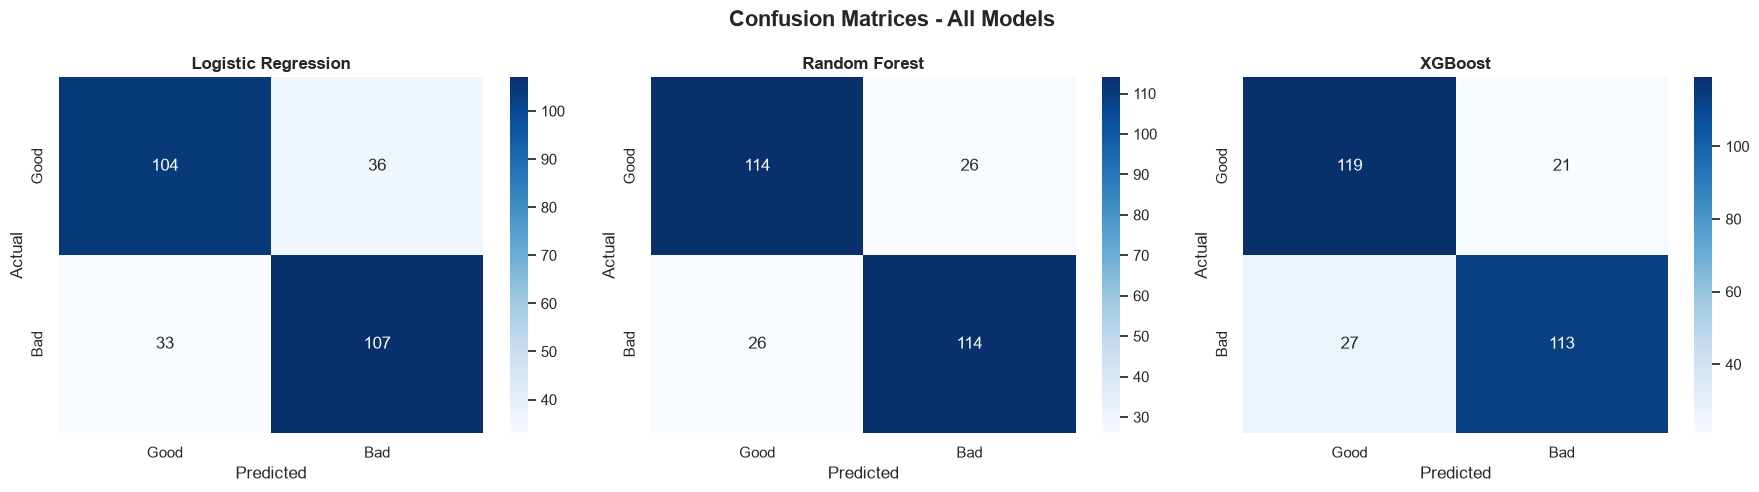

In [5]:
# Confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Good', 'Bad'],
                yticklabels=['Good', 'Bad'],
                ax=axes[i])
    
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

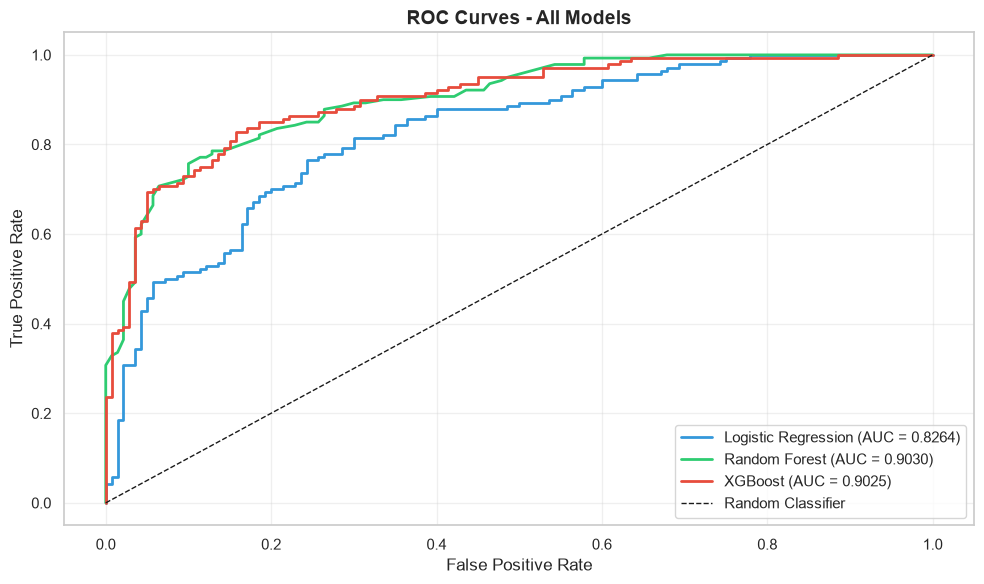

In [6]:
# ROC Curves
plt.figure(figsize=(10, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

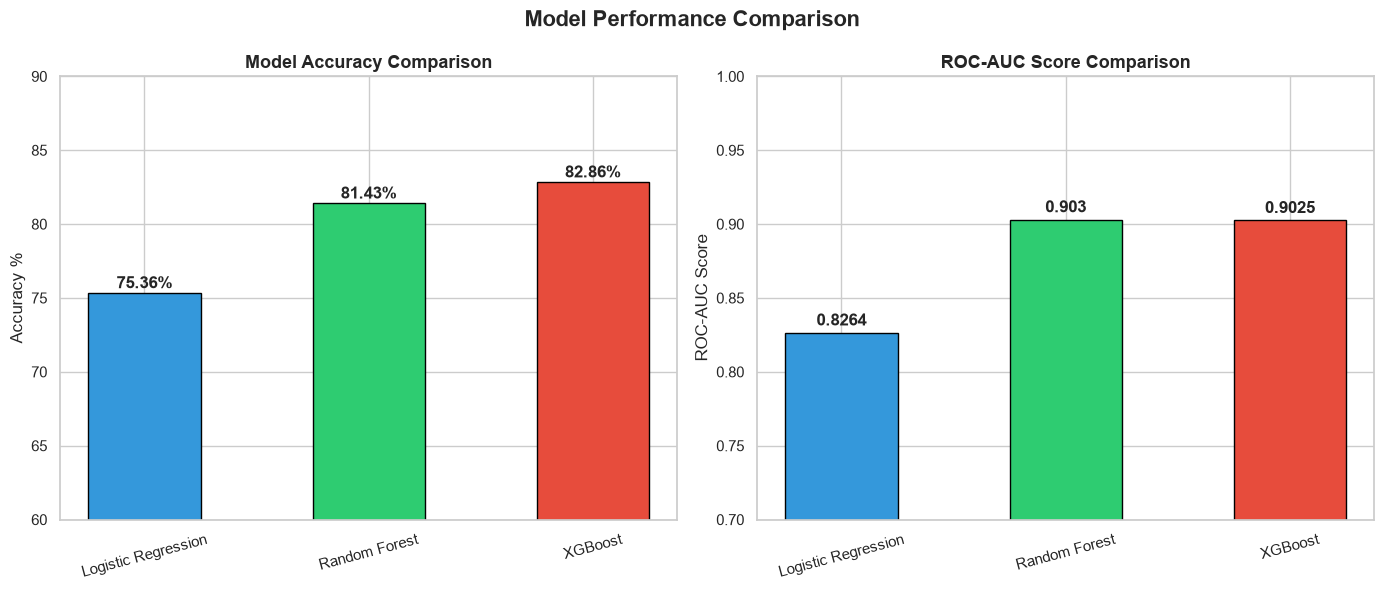

In [8]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_names = list(results.keys())
accuracies = [results[m]['Accuracy'] for m in models_names]
roc_aucs = [results[m]['ROC-AUC'] for m in models_names]
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Accuracy comparison
bars1 = axes[0].bar(models_names, accuracies, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Accuracy %')
axes[0].set_ylim(60, 90)
axes[0].tick_params(axis='x', rotation=15)

for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.3,
                 f'{acc}%', ha='center', fontweight='bold')

# ROC-AUC comparison
bars2 = axes[1].bar(models_names, roc_aucs, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('ROC-AUC Score Comparison', fontweight='bold', fontsize=13)
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0.7, 1.0)
axes[1].tick_params(axis='x', rotation=15)

for bar, auc in zip(bars2, roc_aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{auc}', ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
import joblib
import os

# Create models folder if not exists
os.makedirs('../models', exist_ok=True)

# Save best model (XGBoost)
joblib.dump(xgb_model, '../models/xgb_model.pkl')

# Save all models
joblib.dump(lr_model, '../models/lr_model.pkl')
joblib.dump(rf_model, '../models/rf_model.pkl')

# Save scaler and label encoder for use in app
from sklearn.preprocessing import StandardScaler
joblib.dump(results_df, '../models/results.pkl')

print("All models saved successfully!")
print("\nSaved files:")
print("- models/xgb_model.pkl")
print("- models/lr_model.pkl")
print("- models/rf_model.pkl")
print("- models/results.pkl")

All models saved successfully!

Saved files:
- models/xgb_model.pkl
- models/lr_model.pkl
- models/rf_model.pkl
- models/results.pkl
